# 🔍 Détection de Fraude sur Cartes Bancaires - Modèle Hybride Unique
## Approche Hybride : XGBoost enrichi par le score d'anomalie d'Isolation Forest

Ce notebook présente l'implémentation de la solution la plus performante retenue pour la détection de fraudes : une approche hybride combinant l'apprentissage non supervisé et supervisé.

### Structure du notebook
1. **Chargement et prétraitement** des transactions.
2. **Entraînement de la solution hybride** (Isolation Forest + XGBoost).
3. **Évaluation complète** (Rapport de classification, Courbes ROC & Précision-Rappel).

In [1]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configuration des tracés
%matplotlib inline
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Ajouter le dossier scripts au chemin de recherche
sys.path.append(os.path.abspath('./scripts'))

### 1. Chargement et Prétraitement des Données
Nous utilisons nos modules réutilisables `data_loader` et `data_preprocessing` pour charger et standardiser le dataset.

In [2]:
from data_loader import load_data
from data_preprocessing import preprocess_data

# Chargement des données
df = load_data()

# Prétraitement et partitionnement stratifié (80% Train, 20% Test)
X_train, X_test, y_train, y_test = preprocess_data(df)

Dataset chargé : 284807 lignes, 31 colonnes
Nombre de fraudes : 492
Nombre de transactions normales : 284315


Train set : 227845 lignes
Test set : 56962 lignes
Fraudes dans train : 394
Fraudes dans test : 98


### 2. Entraînement de la Solution Hybride
Nous lançons l'entraînement hybride en appelant la fonction `train_hybrid_model` de notre module `model_training` :

In [3]:
from model_training import train_hybrid_model

# Entraînement de l'Isolation Forest + XGBoost
xgb_model, iso_forest, y_pred, y_proba = train_hybrid_model(X_train, y_train, X_test, y_test)


>>> 1. Entraînement de l'Isolation Forest (Non supervisé) pour calculer le score d'anomalie...


>>> 2. Entraînement de XGBoost (Supervisé) avec la feature d'anomalie...


### 3. Évaluation et Visualisation des Performances
Nous générons le rapport de classification complet et traçons les courbes de performances côte-à-côte à l'aide de `evaluate_hybrid_model` :

In [4]:
from model_evaluation import evaluate_hybrid_model

# Génération des métriques et de la figure contenant les courbes ROC et PR
evaluate_hybrid_model(y_test, y_pred, y_proba)


=== EVALUATION DU MODELE HYBRIDE (XGBoost + Isolation Forest) ===
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     56864
      Fraude       0.93      0.83      0.88        98

    accuracy                           1.00     56962
   macro avg       0.97      0.91      0.94     56962
weighted avg       1.00      1.00      1.00     56962

Précision           : 0.9310
Rappel (Recall)     : 0.8265
F1-Score            : 0.8757
ROC-AUC             : 0.9774
PR-AUC (AUPRC)      : 0.8628



Graphique combiné sauvegardé sous : C:\Users\user\Credit-card-fraud-detection\credit-card-fraud-detection\plots\hybrid_model_curves.png


### 4. Affichage Direct des Courbes de Performances
Affichons directement la figure sauvegardée dans le dossier `plots/`.

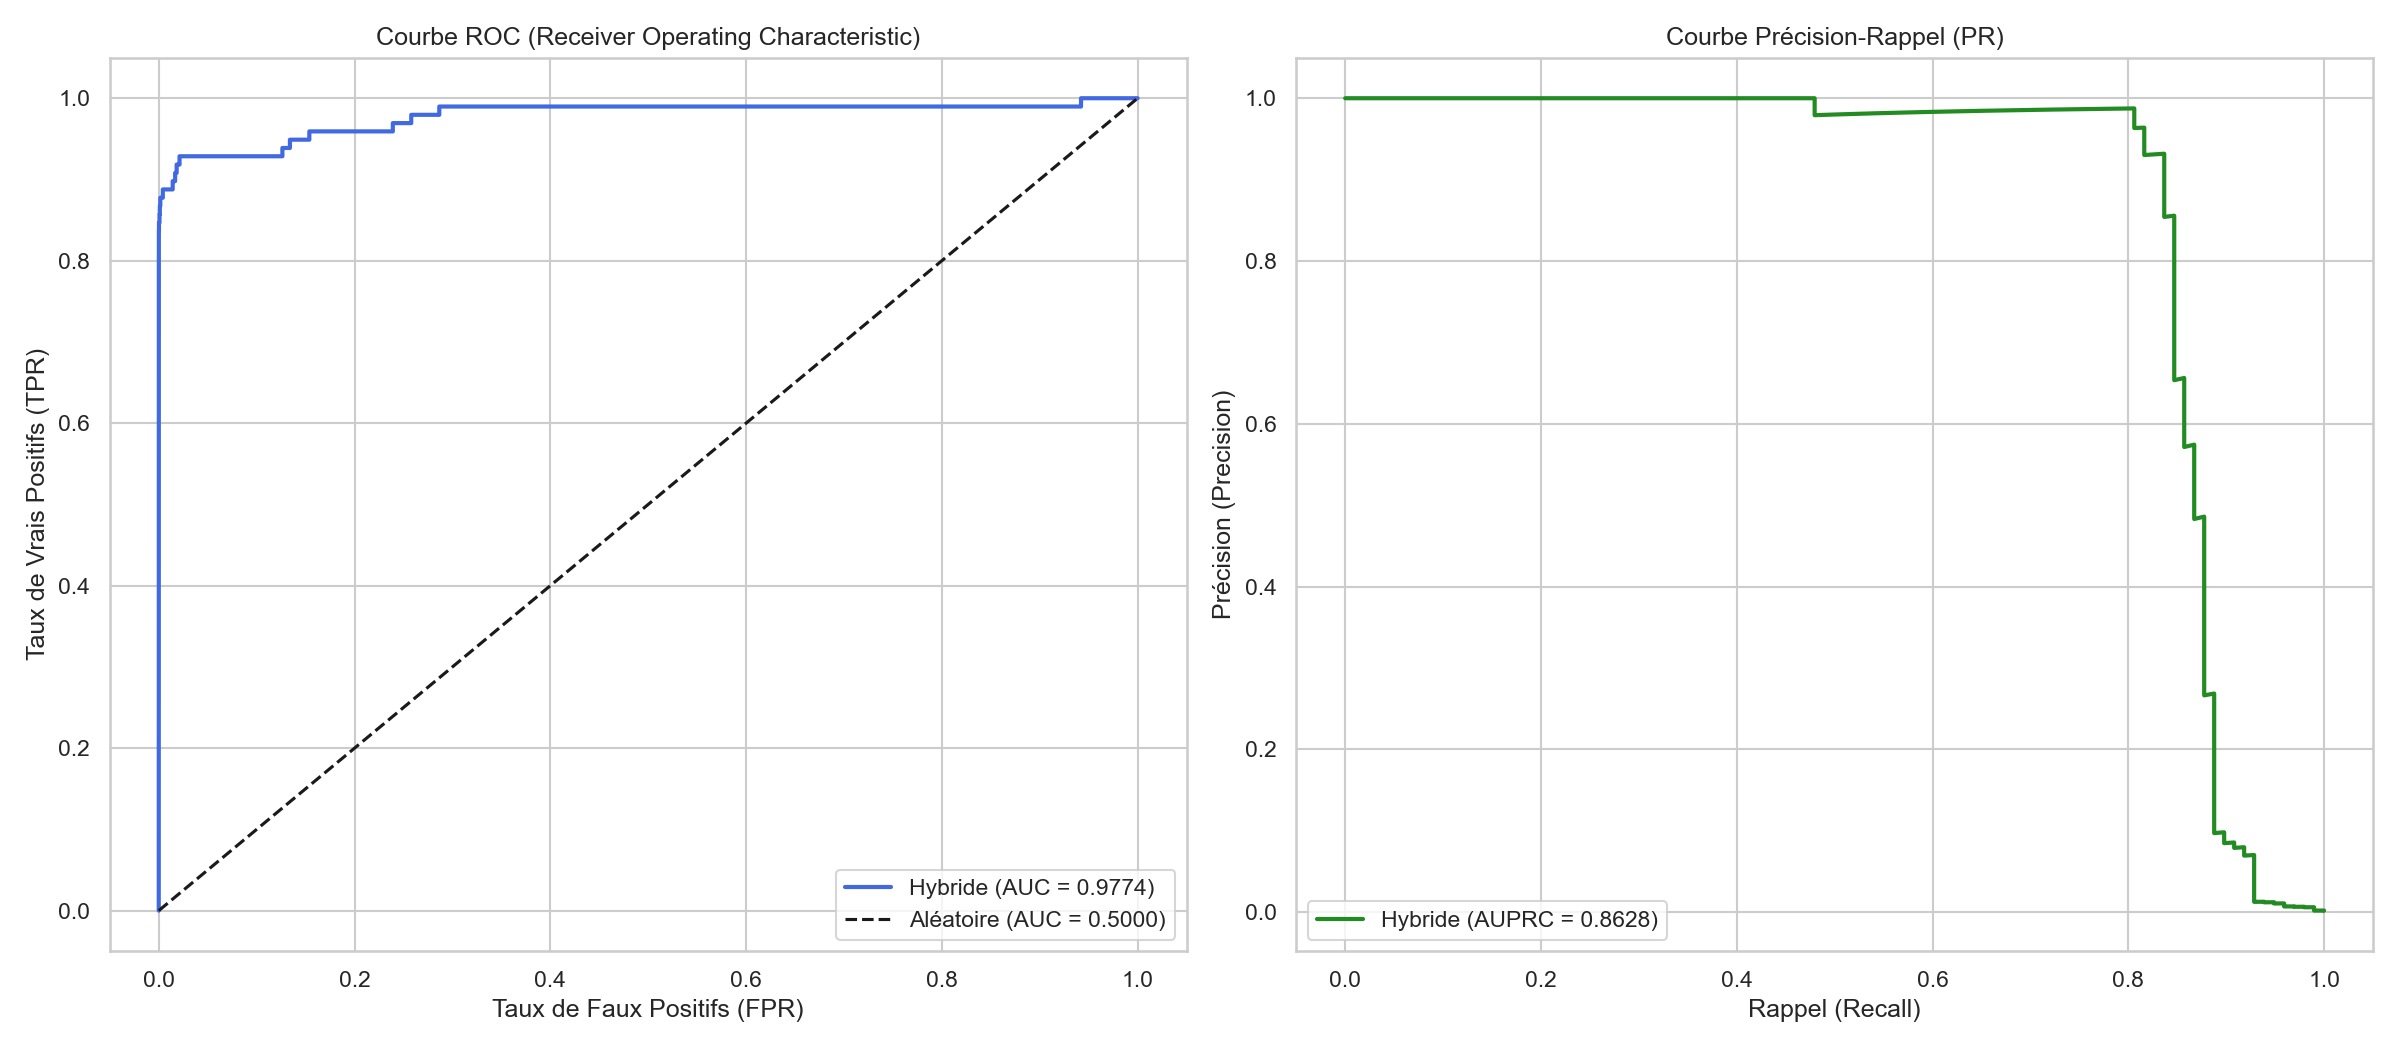

In [5]:
from PIL import Image

# Affichage du graphique combiné
img_curves = Image.open('plots/hybrid_model_curves.png')
display(img_curves)